# **Imports**

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


# **Load Images**

In [26]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []

    label = os.path.basename(folder_path)  # Extract the label from the folder name

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):  # Check if it is a file
            img = cv2.imread(img_path)
            if img is not None:  # Check if the image was read correctly
                img = cv2.resize(img, image_size)  # Resize images to a common size
                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/anikdas1124/indian-uav-soyabean/INDIAN _UAV"

# Load images for each type of chest X-ray
data_Healthy_Soyabean, labels_Healthy_Soyabean = load_images(os.path.join(dataset_path, 'Healthy_Soyabean'))
data_rust, labels_rust = load_images(os.path.join(dataset_path, 'rust'))
data_Soyabean_Mosaic, labels_Soyabean_Mosaic = load_images(os.path.join(dataset_path, 'Soyabean_Mosaic'))
data_Soyabean_Semilooper_Pest_Attack, labels_Soyabean_Semilooper_Pest_Attack = load_images(os.path.join(dataset_path, 'Soyabean Semilooper_Pest_Attack'))

print("Images loaded successfully.")

Images loaded successfully.


# Concatenate

In [27]:
All_data = np.concatenate([
    data_Healthy_Soyabean,
    data_rust,
    data_Soyabean_Mosaic,
    data_Soyabean_Semilooper_Pest_Attack
])

All_labels = np.concatenate([
    labels_Healthy_Soyabean,
    labels_rust,
    labels_Soyabean_Mosaic,
    labels_Soyabean_Semilooper_Pest_Attack
])

print("Data concatenated successfully.")

Data concatenated successfully.


# **Normalization**

In [28]:
All_data_normalized = All_data / 255.0

print("Data normalized successfully.")

Data normalized successfully.


# **Encode & Split**

In [29]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42
)

print("Labels encoded and data split successfully.")

Labels encoded and data split successfully.


# **Plot Data Distribution**

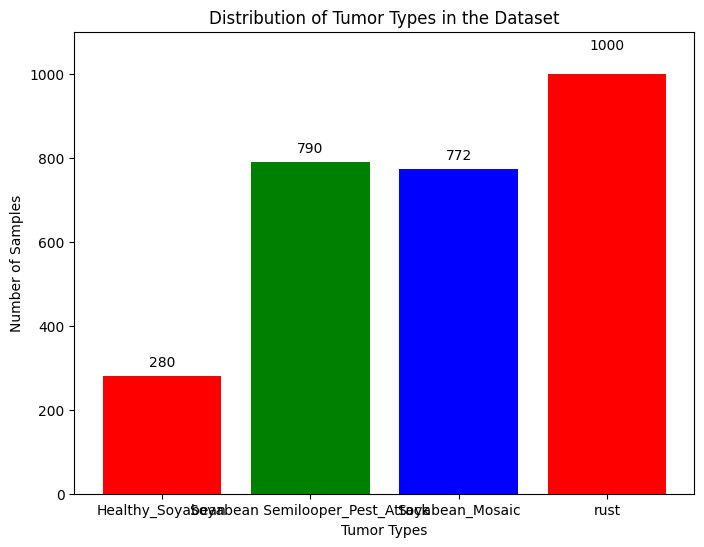

Data distribution plotted successfully.


In [30]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(8, 6))

plt.bar(unique_labels, label_counts, color=['red', 'green', 'blue'])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')

max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)

for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom' if count > 0.9 * max_count else 'top')

plt.show()

print("Data distribution plotted successfully.")

# FPN - RF - C3

In [31]:
def build_c3_only_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (same 3 conv blocks, but only C3 used)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    # Lateral 1x1 on C3 only
    l3 = layers.Conv2D(fpn_channels, 1, padding='same')(c3)

    # No top-down fusion since C4, C5 are excluded
    p3 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(l3)

    # GAP to vector
    feat_vec = layers.GlobalAveragePooling2D(name="c3_feat")(p3)

    return models.Model(x_in, feat_vec, name="c3_only_feature_extractor")

cnn_model_c3 = build_c3_only_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model_c3.summary()

print("C3-only FPN model built successfully.")

Model: "c3_only_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 18)     │           504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 18)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c3_feat                         │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,648 (150.97 KB)

 Trainable params: 38,648 (150.97 KB)

 Non-trainable params: 0 (0.00 B)

C3-only FPN model built successfully.


# C3 - feature extraction

In [32]:
train_features_c3 = cnn_model_c3.predict(train_data, batch_size=64, verbose=0)
test_features_c3  = cnn_model_c3.predict(test_data,  batch_size=64, verbose=0)

def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features_c3 = l2_normalize(train_features_c3)
test_features_c3  = l2_normalize(test_features_c3)

train_features_c3_flattened = np.reshape(train_features_c3, (train_features_c3.shape[0], -1))
test_features_c3_flattened  = np.reshape(test_features_c3,  (test_features_c3.shape[0], -1))

print("C3-only features extracted successfully.")

C3-only features extracted successfully.


# Random Forest,C3

In [33]:
rf_model_c3 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model_c3.fit(train_features_c3_flattened, train_labels)

rf_pred_labels_c3 = rf_model_c3.predict(test_features_c3_flattened)
rf_pred_probs_c3  = rf_model_c3.predict_proba(test_features_c3_flattened)

print("Random Forest (C3 only) trained successfully.")

Random Forest (C3 only) trained successfully.


# confusion matrix - c3

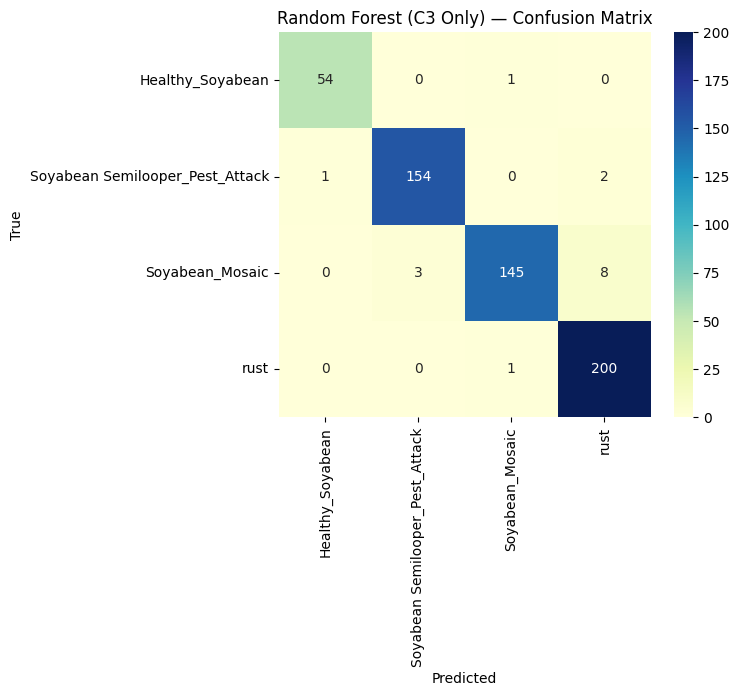

C3 Confusion matrix plotted successfully.


In [34]:
rf_cm_c3 = confusion_matrix(test_labels, rf_pred_labels_c3)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm_c3, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Random Forest (C3 Only) — Confusion Matrix")
plt.show()

print("C3 Confusion matrix plotted successfully.")

# classification report - c3

In [35]:
print("Random Forest (C3 Only) — Classification Report\n",
      classification_report(test_labels, rf_pred_labels_c3,
                             target_names=label_encoder.classes_, digits=4))

print(f"C3-Only Accuracy: {accuracy_score(test_labels, rf_pred_labels_c3):.4f}")

print("C4-Classification report generated successfully.")

Random Forest (C3 Only) — Classification Report
                                  precision    recall  f1-score   support

               Healthy_Soyabean     0.9818    0.9818    0.9818        55
Soyabean Semilooper_Pest_Attack     0.9809    0.9809    0.9809       157
                Soyabean_Mosaic     0.9864    0.9295    0.9571       156
                           rust     0.9524    0.9950    0.9732       201

                       accuracy                         0.9719       569
                      macro avg     0.9754    0.9718    0.9733       569
                   weighted avg     0.9724    0.9719    0.9718       569

C3-Only Accuracy: 0.9719
C4-Classification report generated successfully.


# Multiclass ROC - c3

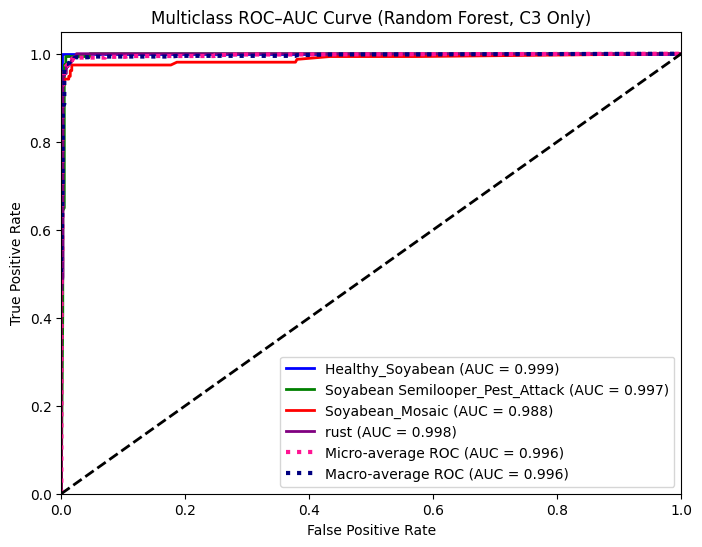

C-3 - ROC-AUC curve plotted successfully.


In [36]:
num_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(test_labels, classes=range(num_classes))
y_pred_proba = rf_pred_probs_c3

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8,6))
colors = ["blue", "green", "red", "purple"]
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=3,
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=3,
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve (Random Forest, C3 Only)")
plt.legend(loc="lower right")
plt.show()

print("C-3 - ROC-AUC curve plotted successfully.")